# 10 · GNN: 이웃에게서 모으고, 모든 노드에 같은 규칙 쓰기

**질문:** 이미지의 격자나 시간 순서가 아니라, 연결 관계만 주어졌다면 어떤 입력을 모아서 같은 함수를 적용해야 할까요?

인접 행렬 → 합·평균 집계 → message passing backward → graph readout → 그래프 분류 → 순열 검산과 표현 한계를 구현합니다. 00의 행렬곱, 03의 MLP, 05·06의 가중치 공유를 연결합니다.

[그림 보조 파일](../../src/utils/architecture_plots.py) · [이전 Transformer](09_transformer.ipynb) · [전체 경로](../../docs/CURRICULUM.md)

여기서는 작고 조밀한 인접 행렬을 씁니다. 대규모 sparse 연산이나 라이브러리 호출 안에 집계·미분을 숨기지 않고, 계산을 직접 확인하는 것이 목적입니다.

In [1]:
import sys
from pathlib import Path
project_root = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "src/utils/plotting.py").is_file())
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
import numpy as np
from src.utils import setup_plots
from src.utils.gradcheck import numerical_gradient, rel_error
from src.utils.architecture_plots import plot_matrices, plot_curves, plot_graphs
setup_plots()
np.set_printoptions(precision=4, suppress=True)
print("NumPy", np.__version__, "· GNN 준비 완료")

NumPy 2.3.5 · GNN 준비 완료


## 1. 인접 행렬의 방향을 먼저 정하기

노드 수를 M, 특성 폭을 D, 그래프 배치 크기를 B라고 씁니다. `X:(B,M,D)`, `A:(B,M,M)`입니다. **$A_{ij}=1$은 j에서 i로 정보를 보낼 수 있다는 뜻**으로 정합니다. 그러면
$$m_i=\sum_j A_{ij}x_j,\qquad M_{sum}=AX.$$

행 i는 받는 노드, 열 j는 보내는 노드입니다. 무방향 그래프이면 A가 대칭이지만, 방향이 있는 경우도 같은 식으로 처리할 수 있습니다. A의 대각선은 0으로 두고 자기 자신의 정보는 별도 경로로 사용합니다.

평균 집계는 degree $d_i=\sum_j A_{ij}$로 나눕니다.
$$S_{ij}=A_{ij}/\max(d_i,1),\quad M_{mean}=SX.$$
입력 A가 0/1일 때 degree는 들어오는 이웃 수입니다. 이웃이 없는 행은 0으로 남습니다. 이웃 평균만으로 자기 자신을 잃지 않도록 다음 절에서 self 경로를 둡니다.

In [2]:
def aggregation_matrix(A, mode="sum"):
    assert mode in ("sum", "mean")
    assert A.ndim == 3 and A.shape[-1] == A.shape[-2]
    assert np.all((A == 0) | (A == 1)), "이 구현의 입력 인접 행렬은 0/1입니다"
    if mode == "sum":
        return A
    degree = A.sum(axis=-1, keepdims=True)
    return A / np.maximum(degree, 1)


def aggregate_loops(X, S):
    B, M, D = X.shape
    messages = np.zeros_like(X)
    for b in range(B):
        for i in range(M):
            for j in range(M):
                messages[b, i] += S[b, i, j] * X[b, j]
    return messages

In [3]:
A_hand = np.array([[[0., 1., 1.], [0., 0., 0.], [1., 0., 0.]]])
X_hand = np.array([[[1., 2.], [3., 4.], [5., 8.]]])
sum_messages = A_hand @ X_hand
mean_messages = aggregation_matrix(A_hand, "mean") @ X_hand
np.testing.assert_allclose(sum_messages[0], [[8, 12], [0, 0], [1, 2]])
np.testing.assert_allclose(mean_messages[0], [[4, 6], [0, 0], [1, 2]])
np.testing.assert_allclose(aggregate_loops(X_hand, A_hand), sum_messages)
print("노드 0은 노드 1·2에서 받고, 노드 1은 받는 이웃이 없습니다")

노드 0은 노드 1·2에서 받고, 노드 1은 받는 이웃이 없습니다


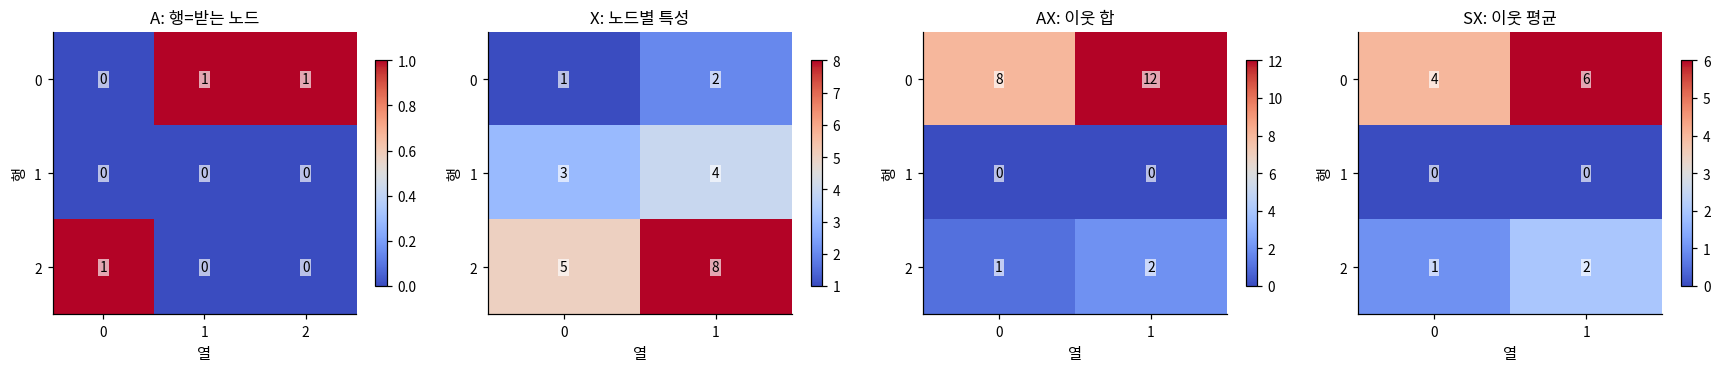

In [4]:
plot_matrices([A_hand[0], X_hand[0], sum_messages[0], mean_messages[0]],
              ["A: 행=받는 노드", "X: 노드별 특성", "AX: 이웃 합", "SX: 이웃 평균"])

## 2. 한 층의 message passing과 backward

모든 노드가 같은 두 가중치를 사용하게 만듭니다.
$$Z=XW_s+(SX)W_n+b,\qquad H=\tanh(Z).$$
$W_s,W_n:(D,H)$입니다. self 경로와 neighbor 경로에 다른 가중치를 쓰되, 노드 번호에 따라 별도 가중치를 만들지 않습니다. 파라미터 수는 $2DH+H$로 노드 수에 의존하지 않습니다.

상류 기울기를 $dH$라 두면 $dZ=dH\odot(1-H^2)$입니다. $R=SX$라 쓰고
$$dW_s=\sum_b X_b^TdZ_b,\quad dW_n=\sum_bR_b^TdZ_b,\quad db=\sum_{b,i}dZ_{b,i},$$
$$dR=dZW_n^T,\qquad dX=dZW_s^T+S^TdR.$$

forward에서는 보내는 j를 모아 받는 i에 합했습니다. backward에서는 받는 i에서 돌아온 기여를 보내는 j에 누적하므로 **S의 전치**가 등장합니다. 평균 집계의 S는 무방향 A에서 만들어도 degree가 다르면 대칭이 아닐 수 있습니다.

A는 이번 모델에서 주어진 고정 연결입니다. 이산 edge의 추가·삭제를 미분하거나 A 자체를 학습하지 않습니다.

In [5]:
def gnn_layer_forward(X, A, p, mode="sum"):
    S = aggregation_matrix(A, mode)
    messages = S @ X
    Z = X @ p["Ws"] + messages @ p["Wn"] + p["b"]
    H = np.tanh(Z)
    return H, (X, S, messages, H)


def gnn_layer_backward(dH, cache, p):
    X, S, messages, H = cache
    dZ = dH * (1 - H ** 2)
    D, width = X.shape[-1], H.shape[-1]
    grads = {"Ws": X.reshape(-1, D).T @ dZ.reshape(-1, width),
             "Wn": messages.reshape(-1, D).T @ dZ.reshape(-1, width),
             "b": dZ.sum(axis=(0, 1))}
    dmessages = dZ @ p["Wn"].T
    dX = dZ @ p["Ws"].T + S.swapaxes(-1, -2) @ dmessages
    return dX, grads


def check_gnn_layer(candidate):
    rng = np.random.default_rng(101)
    errors = {}
    A = np.array([[[0., 1., 1., 0.], [0., 0., 0., 0.], [1., 0., 0., 0.], [0., 0., 0., 0.]],
                  [[0., 0., 1., 0.], [1., 0., 0., 0.], [0., 1., 0., 0.], [0., 0., 0., 0.]]])
    for mode in ["sum", "mean"]:
        X = rng.normal(size=(2, 4, 2))
        p = {"Ws": rng.normal(size=(2, 3)) * 0.3, "Wn": rng.normal(size=(2, 3)) * 0.3,
             "b": rng.normal(size=3) * 0.2}
        H, cache = gnn_layer_forward(X, A, p, mode)
        G = rng.normal(size=H.shape)
        dX, grads = candidate(G, cache, p)
        scalar = lambda: float(np.sum(gnn_layer_forward(X, A, p, mode)[0] * G))
        entries = [("X", X, dX)] + [(k, v, grads[k]) for k, v in p.items()]
        for name, value, grad in entries:
            error = rel_error(grad, numerical_gradient(scalar, value))
            assert np.isfinite(error) and error < 2e-6, (mode, name, error)
            errors[f"{mode}/{name}"] = error
    return errors

In [6]:
gnn_layer_errors = check_gnn_layer(gnn_layer_backward)
print("합·평균, 방향·고립 노드의 최대 미분 상대오차:", max(gnn_layer_errors.values()))

합·평균, 방향·고립 노드의 최대 미분 상대오차: 1.9854066525716172e-10


## 3. 층을 쌓으면 읽는 범위가 넓어집니다

한 층은 self와 1-hop 이웃을 읽습니다. 두 층은 최대 2-hop까지의 정보를 받을 수 있습니다. 모든 멀리 떨어진 노드의 정보를 즉시 볼 수 있는 것은 아닙니다. 아래는 일렬로 연결한 5노드의 가능한 영향 경로를 계산한 그림입니다. `(I+A)^2`의 양수 위치는 두 번의 self/이웃 전달로 도달하는 쌍입니다. 실제 학습된 가중치에 따라 기여가 0이 될 수도 있어, 이는 **가능한 연결 범위**입니다.

노드 분류는 각 $H_i$에 head를 붙입니다. 그래프 분류는 노드 전체를 모은 readout이 필요합니다. 여기서는 평균
$$r=\frac1M\sum_iH_i,\quad logits=rW_o+b_o$$
를 사용합니다. backward에서 각 노드는 같은 $dr/M$을 받습니다. 노드 수가 다른 그래프를 padding해 한 배치로 합치면 유효 노드만 합하고 실제 노드 수로 나눠야 합니다. 이번 구현은 한 배치 안의 M이 같고 padding은 없습니다.

In [7]:
def path_adjacency(M):
    A = np.zeros((M, M))
    for i in range(M - 1):
        A[i, i + 1] = A[i + 1, i] = 1
    return A


def star_adjacency(M):
    A = np.zeros((M, M))
    A[0, 1:] = A[1:, 0] = 1
    return A


def graph_forward(X, A, layers, head, mode="sum"):
    H1, cache1 = gnn_layer_forward(X, A, layers[0], mode)
    H2, cache2 = gnn_layer_forward(H1, A, layers[1], mode)
    readout = H2.mean(axis=1)
    return readout @ head["W"] + head["b"], (cache1, cache2, H2.shape, readout)


def graph_backward(dlogits, cache, layers, head, layer_backward_fn=gnn_layer_backward):
    cache1, cache2, shape, readout = cache
    dhead = {"W": readout.T @ dlogits, "b": dlogits.sum(axis=0)}
    dreadout = dlogits @ head["W"].T
    dH2 = np.broadcast_to((dreadout / shape[1])[:, None, :], shape)
    dH1, grad2 = layer_backward_fn(dH2, cache2, layers[1])
    dX, grad1 = layer_backward_fn(dH1, cache1, layers[0])
    return dX, [grad1, grad2], dhead


def init_graph(D=1, H=8, seed=102):
    rng = np.random.default_rng(seed)
    layers = [{"Ws": rng.normal(size=(din, H)) * 0.5 / np.sqrt(din),
               "Wn": rng.normal(size=(din, H)) * 0.2 / np.sqrt(din), "b": np.zeros(H)} for din in [D, H]]
    head = {"W": rng.normal(size=(H, 2)) / np.sqrt(H), "b": np.zeros(2)}
    return layers, head

In [8]:
path5 = path_adjacency(5)
one_hop = (np.eye(5) + path5) > 0
two_hop = ((np.eye(5) + path5) @ (np.eye(5) + path5)) > 0
# 그래프 분류 전체의 입력·모든 파라미터도 독립적인 스칼라와 비교합니다.
probe_X = np.random.default_rng(103).normal(size=(2, 3, 2))
probe_A = np.stack([path_adjacency(3), A_hand[0]])
probe_layers, probe_head = init_graph(2, 3, 104)
probe_logits, probe_cache = graph_forward(probe_X, probe_A, probe_layers, probe_head)
G = np.random.default_rng(105).normal(size=probe_logits.shape)
dX, d_layers, d_head = graph_backward(G, probe_cache, probe_layers, probe_head)
scalar = lambda: float(np.sum(graph_forward(probe_X, probe_A, probe_layers, probe_head)[0] * G))
graph_errors = {"X": rel_error(dX, numerical_gradient(scalar, probe_X))}
for i, (params, grads) in enumerate(zip([*probe_layers, probe_head], [*d_layers, d_head])):
    for k, value in params.items():
        graph_errors[f"{i}/{k}"] = rel_error(grads[k], numerical_gradient(scalar, value))
assert max(graph_errors.values()) < 2e-6
print("2층·readout·head 전체 최대 미분 상대오차:", max(graph_errors.values()))

2층·readout·head 전체 최대 미분 상대오차: 5.576446392942628e-10


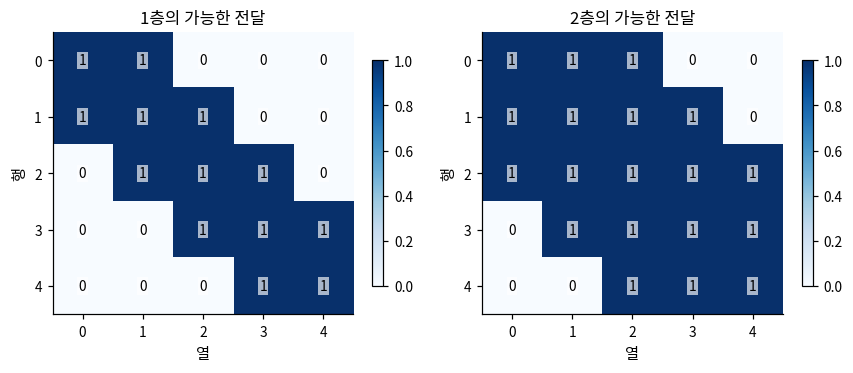

In [9]:
plot_matrices([one_hop.astype(int), two_hop.astype(int)], ["1층의 가능한 전달", "2층의 가능한 전달"], cmap="Blues")

## 4. 완성 학습: 사슬 모양과 별 모양 그래프 분류

두 그래프는 노드 6개·edge 5개로 같습니다. 초기 특성은 모든 노드에서 1에 작은 잡음을 더한 값입니다. 연결의 형태를 읽어야 합니다. 학습 128개·검증 64개는 두 기본 그래프를 독립적으로 노드 순열·잡음으로 변형합니다. 이는 **두 모양의 새 순열·잡음**에 대한 평가이며, 임의의 새로운 그래프 종류에 대한 성능은 아닙니다.

합 집계→tanh를 두 번 거쳐 평균 readout으로 분류합니다. 잡음을 빼고 초기 특성을 모두 같은 값으로 고정하면, 선형으로 한 번 집계한 뒤 바로 평균낼 때 두 그래프의 평균 degree가 같아 구별하지 못합니다. 잡음 특성에서는 이 등식이 항상 성립하지 않으므로 이 조건을 분리해서 생각합니다. 비선형 노드 표현이 degree의 분포와 이웃 구성을 구별할 기회를 만듭니다.

In [10]:
def graph_data(n, M, seed):
    rng = np.random.default_rng(seed)
    y = np.arange(n) % 2
    rng.shuffle(y)
    matrices = []
    for label in y:
        A = path_adjacency(M) if label == 0 else star_adjacency(M)
        permutation = rng.permutation(M)
        matrices.append(A[permutation][:, permutation])
    X = 1 + rng.normal(0, 0.03, size=(n, M, 1))
    return X, np.stack(matrices), y


def ce_loss(logits, y):
    z = logits - logits.max(axis=-1, keepdims=True)
    logp = z - np.log(np.exp(z).sum(axis=-1, keepdims=True))
    grad = np.exp(logp)
    grad[np.arange(len(y)), y] -= 1
    return -logp[np.arange(len(y)), y].mean(), grad / len(y)


def adam_step(p, grads, state, step, lr=0.02):
    for key in p:
        m, v = state[key]
        m = 0.9 * m + 0.1 * grads[key]
        v = 0.999 * v + 0.001 * grads[key] ** 2
        p[key] -= lr * (m / (1 - 0.9 ** step)) / (np.sqrt(v / (1 - 0.999 ** step)) + 1e-8)
        state[key] = (m, v)

In [11]:
path6, star6 = path_adjacency(6), star_adjacency(6)
angles = np.arange(6) * 2 * np.pi / 6
circle = np.stack([np.cos(angles), np.sin(angles)], axis=1)
star_positions = np.vstack([np.zeros(2), np.stack([np.cos(angles[:5] * 6/5), np.sin(angles[:5] * 6/5)], axis=1)])
line_positions = np.stack([np.arange(6), np.zeros(6)], axis=1)
np.testing.assert_allclose(path6.sum(axis=1).mean(), star6.sum(axis=1).mean())
print("path degree:", path6.sum(axis=1), "· star degree:", star6.sum(axis=1))
print("두 그래프 평균 degree:", path6.sum(axis=1).mean())

path degree:

 [1. 2. 2. 2. 2. 1.] · star degree: [5. 1. 1. 1. 1. 1.]
두 그래프 평균 degree: 1.6666666666666667


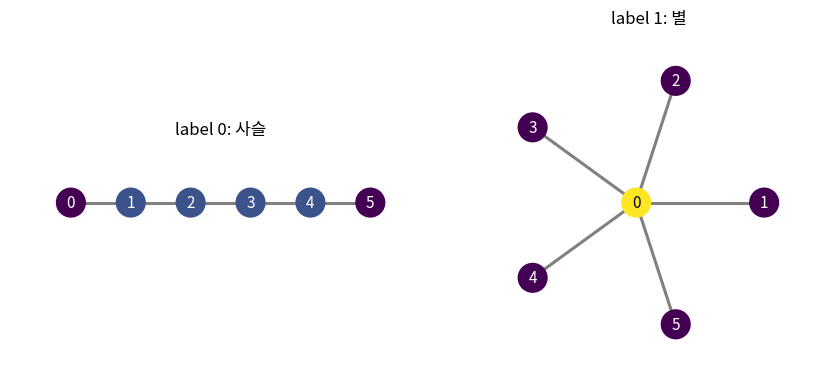

In [12]:
plot_graphs([path6, star6], [line_positions, star_positions],
            [path6.sum(axis=1), star6.sum(axis=1)], ["label 0: 사슬", "label 1: 별"])

In [13]:
X_train, A_train, y_train = graph_data(128, 6, 106)
X_valid, A_valid, y_valid = graph_data(64, 6, 107)
layers, head = init_graph()
params_all = [*layers, head]
states = [{k: (np.zeros_like(v), np.zeros_like(v)) for k, v in params.items()} for params in params_all]
history = {"step": [], "train": [], "valid": []}
for step in range(351):
    logits, cache = graph_forward(X_train, A_train, layers, head)
    loss, dlogits = ce_loss(logits, y_train)
    if step % 35 == 0:
        valid_logits, _ = graph_forward(X_valid, A_valid, layers, head)
        history["step"].append(step)
        history["train"].append(loss)
        history["valid"].append(ce_loss(valid_logits, y_valid)[0])
    if step == 350:
        break
    _, d_layers, d_head = graph_backward(dlogits, cache, layers, head)
    for params, grads, state in zip(params_all, [*d_layers, d_head], states):
        adam_step(params, grads, state, step + 1)
accuracy = np.mean(valid_logits.argmax(axis=-1) == y_valid)
print(f"학습 CE {history['train'][0]:.6f} → {history['train'][-1]:.6f}")
print(f"검증 CE {history['valid'][-1]:.6f}, 정확도 {accuracy:.1%}, 파라미터 {sum(v.size for p in params_all for v in p.values())}")
assert accuracy > 0.95 and history["train"][-1] < 0.1

학습 CE 0.688424 → 0.000157
검증 CE 0.000155, 정확도 100.0%, 파라미터 178


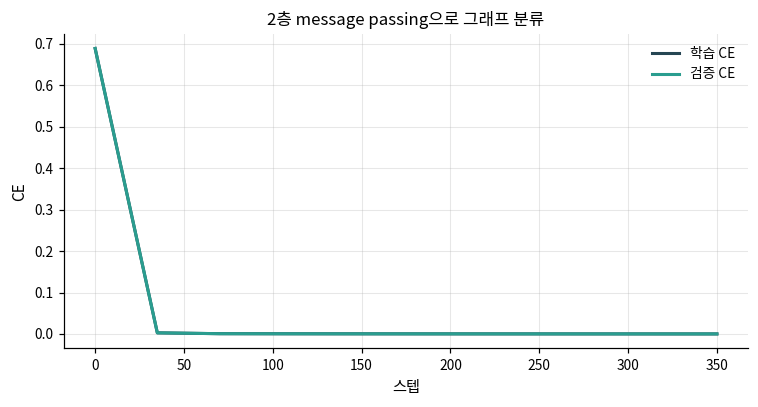

In [14]:
plot_curves(history["step"], {"학습 CE": history["train"], "검증 CE": history["valid"]},
            title="2층 message passing으로 그래프 분류", ylabel="CE")

## 5. 노드 번호를 바꾸어도 같은 그래프입니다

순열 행렬 $\Pi$로 노드를 재배열하면 $X'=\Pi X$, $A'=\Pi A\Pi^T$입니다. 받는 행과 보내는 열을 **둘 다** 바꿔야 같은 그래프를 나타냅니다. 그러면 $S'=\Pi S\Pi^T$이므로
$$S'X'=\Pi SX,\qquad H'=\Pi H.$$

노드별 출력은 같은 순서로 바뀌는 **equivariance**, 평균 readout과 그래프 logits는 그대로인 **invariance**를 갖습니다. 이 성질은 파라미터 학습 전후 모두 수식에서 나옵니다.

Backward에서도 상류 노드 기울기를 같은 순열로 바꾸면 dX는 같은 순열로 바뀌고, 공유 파라미터의 미분은 같습니다. 출력만 확인하지 않고 이 연결까지 검사합니다.

In [15]:
permutation = np.array([4, 1, 5, 0, 3, 2])
Xp = X_valid[:3, permutation]
Ap = A_valid[:3, permutation][:, :, permutation]
for mode in ["sum", "mean"]:
    H, cache = gnn_layer_forward(X_valid[:3], A_valid[:3], layers[0], mode)
    Hp, cachep = gnn_layer_forward(Xp, Ap, layers[0], mode)
    np.testing.assert_allclose(Hp, H[:, permutation], atol=1e-12)
    logits, _ = graph_forward(X_valid[:3], A_valid[:3], layers, head, mode)
    logitsp, _ = graph_forward(Xp, Ap, layers, head, mode)
    np.testing.assert_allclose(logitsp, logits, atol=1e-12)
    G = np.random.default_rng(108).normal(size=H.shape)
    dx, grads = gnn_layer_backward(G, cache, layers[0])
    dxp, gradsp = gnn_layer_backward(G[:, permutation], cachep, layers[0])
    np.testing.assert_allclose(dxp, dx[:, permutation], atol=1e-12)
    for key in grads:
        np.testing.assert_allclose(gradsp[key], grads[key], atol=1e-12)
    print(mode, "노드 출력·입력 미분 대응 / 그래프 출력·공유 미분 불변 통과")

sum 노드 출력·입력 미분 대응 / 그래프 출력·공유 미분 불변 통과
mean 노드 출력·입력 미분 대응 / 그래프 출력·공유 미분 불변 통과


## 6. 표현력의 한계도 같은 코드로 확인하기

**첫 번째 한계: 평균 집계는 개수를 잃을 수 있습니다.** 모든 초기 노드 특성이 같고 고립 노드가 없다면, path와 star의 이웃 평균은 둘 다 그 같은 특성입니다. 이후 층도 모든 노드에 같은 규칙을 적용하므로 두 그래프의 평균 readout을 구별하지 못합니다. degree를 입력 특성에 넣거나 합 집계를 쓰면 이 특정 정보 손실을 피할 수 있습니다.

**두 번째 한계: 합 집계도 모든 그래프를 구별하지는 못합니다.** 6개 노드의 한 고리와, 각각 3개 노드로 된 분리된 두 고리는 모든 노드의 degree가 2입니다. 초기 특성이 모두 같으면 두 그래프의 각 노드는 매 층 같은 이웃 값 두 개를 받아 같은 표현을 가집니다. 이 message passing과 평균 readout으로는 연결성 차이를 구별할 수 없습니다.

이는 단순히 학습이 덜 된 현상이 아니라, 여기서 정의한 입력과 집계가 구별에 필요한 정보를 전달하지 않는 사례입니다. 모든 GNN 구조에 대한 불가능성 주장으로 넓히지는 않습니다.

In [16]:
constant_X = np.ones((2, 6, 1))
path_star = np.stack([path6, star6])
mean_logits, _ = graph_forward(constant_X, path_star, layers, head, mode="mean")
np.testing.assert_allclose(mean_logits[0], mean_logits[1], atol=1e-12)
cycle6 = path6.copy()
cycle6[0, -1] = cycle6[-1, 0] = 1
triangles = np.zeros((6, 6))
triangles[:3, :3] = np.ones((3, 3)) - np.eye(3)
triangles[3:, 3:] = np.ones((3, 3)) - np.eye(3)
regular_pair = np.stack([cycle6, triangles])
regular_logits, _ = graph_forward(constant_X, regular_pair, layers, head, mode="sum")
np.testing.assert_allclose(regular_logits[0], regular_logits[1], atol=1e-12)
triangle_angles = np.arange(3) * 2 * np.pi / 3
triangle_base = np.stack([np.cos(triangle_angles), np.sin(triangle_angles)], axis=1) * 0.6
triangle_positions = np.vstack([triangle_base + [-1.2, 0], triangle_base + [1.2, 0]])
print("평균 집계의 path/star logits 차이:", np.max(np.abs(mean_logits[0] - mean_logits[1])))
print("합 집계의 한 고리/두 고리 logits 차이:", np.max(np.abs(regular_logits[0] - regular_logits[1])))

평균 집계의 path/star logits 차이: 0.0
합 집계의 한 고리/두 고리 logits 차이: 0.0


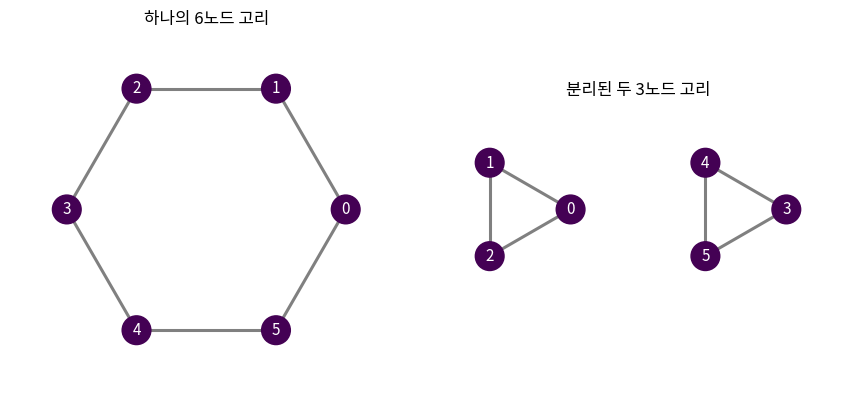

In [17]:
plot_graphs([cycle6, triangles], [circle, triangle_positions], [np.ones(6), np.ones(6)],
            ["하나의 6노드 고리", "분리된 두 3노드 고리"])

## 7. 직접 바꾸고 검사하기

1. `my_gnn_layer_backward(dH, cache, p)`를 새 셀에 쓰고 `check_gnn_layer(my_gnn_layer_backward)`를 실행하세요. 이 검사에는 비대칭 A, 받는 이웃만 없는 노드, 들어오고 나가는 연결이 모두 없는 고립 노드가 있어 전치·0 degree 처리 실수를 숨기지 않습니다.
2. 위 5절의 순열 검사에도 자신의 backward를 넣으세요. dX와 dW가 각각 어떻게 바뀌어야 하는지 먼저 적으세요.
3. `graph_data(64,8,109)`로 노드 수를 6→8로 바꾸고 추가 학습 없이 예측해 보세요. 가중치 shape는 그대로지만 데이터의 degree 분포가 달라집니다.
4. 노드 분류로 바꾼다면 평균 readout을 거치지 않고 각 H_i에 head를 붙입니다. logits의 shape와 CE에서 평균낼 유효 노드 수를 먼저 써 보세요.

아래는 이웃 기울기를 forward와 같은 방향으로 보낸 오답입니다.

In [18]:
def wrong_neighbor_direction(dH, cache, p):
    X, S, messages, H = cache
    _, grads = gnn_layer_backward(dH, cache, p)
    dZ = dH * (1 - H ** 2)
    dX = dZ @ p["Ws"].T + S @ (dZ @ p["Wn"].T)
    return dX, grads

In [19]:
try:
    check_gnn_layer(wrong_neighbor_direction)
except AssertionError as error:
    print("의도적 오답 검출: 이웃 미분의 전치 누락", error)
else:
    raise AssertionError("검사기가 오답을 놓쳤습니다")
X8, A8, y8 = graph_data(64, 8, 109)
logits8, _ = graph_forward(X8, A8, layers, head)
print(f"추가 갱신 없는 8노드: CE {ce_loss(logits8, y8)[0]:.6f}, 정확도 {np.mean(logits8.argmax(axis=-1) == y8):.1%}")

의도적 오답 검출: 이웃 미분의 전치 누락 ('sum', 'X', 0.848897776249473)
추가 갱신 없는 8노드: CE 0.000045, 정확도 100.0%


### 공유 방식을 연결하기

| 구조 | 이웃을 정하는 방법 | 파라미터가 공유되는 축 | 입력 기울기가 모이는 이유 |
|---|---|---|---|
| CNN | 공간의 고정된 패치 | 이미지의 위치 | 한 픽셀이 여러 패치에 등장 |
| RNN·LSTM·GRU | 이전 시각의 상태 | 시간 | 같은 상태가 미래 경로와 손실에 사용 |
| GNN | 주어진 edge | 노드·edge의 반복 규칙 | 한 노드가 여러 이웃에게 정보를 전달 |
| Attention·Transformer | Q·K로 계산한 가중치와 mask | 위치의 투영·FFN | 각 값이 여러 query에 읽힘 |

공유는 같은 변수를 여러 계산에 다시 사용한다는 뜻이고, 미분은 그 사용 경로들의 **합**입니다. 이제 구조를 바꿀 때 무엇이 바뀌고 CE·MSE·optimizer 중 무엇을 유지할 수 있는지 구분할 수 있어야 합니다.

### 준비도 확인

- **설명:** 인접 행렬 방향, 자기 경로, 이웃 집계, readout의 역할을 구분할 수 있습니까?
- **수식:** S의 정규화와 전치가 나타나는 위치, 노드 평균의 미분을 쓸 수 있습니까?
- **구현:** 방향·고립 노드·노드 수 변화를 처리하며 공유 미분을 누적할 수 있습니까?
- **변형:** 노드 출력의 equivariance와 그래프 출력의 invariance를 검산하고 구분 불가능한 예를 만들 수 있습니까?

[Gilmer 등의 Message Passing Neural Networks](https://arxiv.org/abs/1704.01212)는 메시지 전달과 readout으로 그래프 모델을 설명하는 틀을 제공합니다. 여기서는 edge 특성 없이 self와 합/평균 이웃을 결합한 교육용 인스턴스를 구현했으며, 특정 GCN·GraphSAGE 라이브러리의 동일 재현은 아닙니다.

기본 아키텍처 05–10을 마쳤습니다. 후속 제작 범위는 [커리큘럼의 11 Autoencoder부터 시작하는 학습 목적과 생성](../../docs/CURRICULUM.md#3-학습-목적과-생성)입니다. 구조·목적함수·갱신·학습 후 사용을 각각 적는 방식으로 이어갑니다.